# Pre-laboratorio

In [1]:
%pip install uncertainties

  Obtaining dependency information for uncertainties from https://files.pythonhosted.org/packages/8f/5e/f1e1dd319e35e962a4e00b33150a8868b6329cc1d19fd533436ba5488f09/uncertainties-3.2.3-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/60.1 kB ? eta -:--:--
   ------ --------------------------------- 10.2/60.1 kB ? eta -:--:--
   ---------------------------------------- 60.1/60.1 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
from scipy.integrate import cumulative_trapezoid, odeint
from scipy.fft import fft, ifft
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from uncertainties import ufloat
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from sympy import symbols, lambdify, sqrt, sin
import math

### Rigidez resortes

In [ ]:

u_instrument = 0.00005   # 50 micras (m)
def procesar_tripleta(lista_cm):
    datos_m = np.array(lista_cm) / 100
    media = np.mean(datos_m)
    std_exp = np.std(datos_m, ddof=1)
    sem = std_exp / np.sqrt(3)
    u_inst_mean = u_instrument / np.sqrt(3)
    u_media = math.sqrt(sem**2 + u_inst_mean**2)
    return media, std_exp, u_media


# DATOS MEDIDOS
alta_init = [
    [9.09, 9.10, 9.10],
    [9.10, 9.10, 9.09],
    [9.30, 9.29, 9.31],
    [9.10, 9.09, 9.10]
]

alta_final = [
    [9.00, 9.01, 8.99],
    [9.00, 8.99, 9.01],
    [9.13, 9.14, 9.135],
    [9.03, 9.025, 9.04]
]

media_init = [
    [9.67, 9.68, 9.70],
    [9.82, 9.79, 9.78],
    [9.80, 9.79, 9.80],
    [9.80, 9.80, 9.79]
]

media_final = [
    [9.19, 9.18, 9.18],
    [9.16, 9.14, 9.14],
    [9.38, 9.36, 9.35],
    [9.35, 9.38, 9.36]
]

baja_init = [
    [9.79, 9.82, 9.79],
    [9.77, 9.79, 9.78],
    [9.60, 9.64, 9.61],
    [9.80, 9.76, 9.81]
]

baja_final = [
    [8.80, 8.90, 8.90],
    [9.00, 8.90, 8.90],
    [8.80, 8.90, 8.89],
    [8.90, 8.88, 8.90]
]

def procesar_config(init_list, final_list, nombre_config):
    resultados = []
    
    for i, (L0, Lf) in enumerate(zip(init_list, final_list), start=1):
        media_L0, std_L0, u_L0 = procesar_tripleta(L0)
        media_Lf, std_Lf, u_Lf = procesar_tripleta(Lf)
        delta = media_Lf - media_L0
        u_delta = math.sqrt(u_L0**2 + u_Lf**2)
        
        resultados.append({
            "config": nombre_config,
            "resorte": f"Resorte {i}", # Identificador del resorte
            "L0 (m)": media_L0, # Longitud inicial media
            "u(L0)": u_L0, # Incertidumbre de L0
            "Lf (m)": media_Lf, # Longitud final media
            "u(Lf)": u_Lf, # Incertidumbre de Lf
            "ΔL (m)": delta, # Cambio de longitud
            "u(ΔL)": u_delta, # Incertidumbre del cambio de longitud
            "std L0 (m)": std_L0, # Desviación estándar de L0
            "std Lf (m)": std_Lf # Desviación estándar de Lf
        })
    
    return resultados

res_alta = procesar_config(alta_init, alta_final, "Alta")
res_media = procesar_config(media_init, media_final, "Media")
res_baja = procesar_config(baja_init, baja_final, "Baja")

df = pd.DataFrame(res_alta + res_media + res_baja)

# Mostrar tabla final
print(df)

    
    

   config    resorte    L0 (m)     u(L0)    Lf (m)     u(Lf)    ΔL (m)  \
0    Alta  Resorte 1  0.090967  0.000044  0.090000  0.000065 -0.000967   
1    Alta  Resorte 2  0.090967  0.000044  0.090000  0.000065 -0.000967   
2    Alta  Resorte 3  0.093000  0.000065  0.091350  0.000041 -0.001650   
3    Alta  Resorte 4  0.090967  0.000044  0.090317  0.000053 -0.000650   
4   Media  Resorte 1  0.096833  0.000093  0.091833  0.000044 -0.005000   
5   Media  Resorte 2  0.097967  0.000124  0.091467  0.000073 -0.006500   
6   Media  Resorte 3  0.097967  0.000044  0.093633  0.000093 -0.004333   
7   Media  Resorte 4  0.097967  0.000044  0.093633  0.000093 -0.004333   
8    Baja  Resorte 1  0.098000  0.000104  0.088667  0.000335 -0.009333   
9    Baja  Resorte 2  0.097800  0.000065  0.089333  0.000335 -0.008467   
10   Baja  Resorte 3  0.096167  0.000124  0.088633  0.000319 -0.007533   
11   Baja  Resorte 4  0.097900  0.000155  0.088933  0.000073 -0.008967   

       u(ΔL)  std L0 (m)  std Lf (m) 

In [ ]:
from uncertainties import ufloat
import numpy as np
# MASA SELECCIONADA 1879.7 g = 1.8797 kg
springMass = ufloat(1.8797, 0.0001)   # kg
# Gravedad 
gravity = ufloat(9.774, 0.001)        # m/s^2
# Conversión y carga de datos (cm → m)
def to_ufloat_list(cm_list):
    return [ufloat(x/100.0, 0.00005) for x in cm_list]   # incertidumbre instrumental

# ---------------- BAJA RIGIDEZ ----------------
ll_baja = [
    to_ufloat_list([9.79, 9.82, 9.79]),
    to_ufloat_list([9.77, 9.79, 9.78]),
    to_ufloat_list([9.60, 9.64, 9.61]),
    to_ufloat_list([9.80, 9.76, 9.81])
]

lf_baja = [
    to_ufloat_list([8.80, 8.90, 8.90]),
    to_ufloat_list([9.00, 8.90, 8.90]),
    to_ufloat_list([8.80, 8.90, 8.89]),
    to_ufloat_list([8.90, 8.88, 8.90])
]

# ---------------- MEDIA RIGIDEZ ----------------
ll_media = [
    to_ufloat_list([9.67, 9.68, 9.70]),
    to_ufloat_list([9.82, 9.79, 9.78]),
    to_ufloat_list([9.80, 9.79, 9.80]),
    to_ufloat_list([9.80, 9.80, 9.79])
]

lf_media = [
    to_ufloat_list([9.19, 9.18, 9.18]),
    to_ufloat_list([9.16, 9.14, 9.14]),
    to_ufloat_list([9.38, 9.36, 9.35]),
    to_ufloat_list([9.35, 9.38, 9.36])
]

# ---------------- ALTA RIGIDEZ ----------------
ll_alta = [
    to_ufloat_list([9.09, 9.10, 9.10]),
    to_ufloat_list([9.10, 9.10, 9.09]),
    to_ufloat_list([9.30, 9.29, 9.31]),
    to_ufloat_list([9.10, 9.09, 9.10])
]

lf_alta = [
    to_ufloat_list([9.00, 9.01, 8.99]),
    to_ufloat_list([9.00, 8.99, 9.01]),
    to_ufloat_list([9.13, 9.14, 9.135]),
    to_ufloat_list([9.03, 9.025, 9.04])
]

# CÁLCULO DE k POR RESORTE 
k_baja = []
k_media = []
k_alta = []

for i in range(len(ll_baja)):

    # ΔL = Lf_avg - L0_avg
    dL_baja = np.mean(lf_baja[i]) - np.mean(ll_baja[i])
    dL_media = np.mean(lf_media[i]) - np.mean(ll_media[i])
    dL_alta = np.mean(lf_alta[i]) - np.mean(ll_alta[i])

    # k = (m g) / |ΔL|
    k_baja.append( springMass * gravity / abs(dL_baja) )
    k_media.append( springMass * gravity / abs(dL_media) )
    k_alta.append( springMass * gravity / abs(dL_alta) )

# Promedios
k_baja = np.mean(k_baja)
k_media = np.mean(k_media)
k_alta = np.mean(k_alta)

print("\nRigidez equivalente (promedio):")
print("k_baja  =", k_baja)
print("k_media =", k_media)
print("k_alta  =", k_alta)



Rigidez equivalente (promedio):
k_baja  = 2157+/-5
k_media = 3745+/-17
k_alta  = (1.94+/-0.05)e+04


C:\Users\miloa\AppData\Local\Temp\ipykernel_29748\1908838421.py:69: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  k_baja.append( springMass * gravity / abs(dL_baja) )
C:\Users\miloa\AppData\Local\Temp\ipykernel_29748\1908838421.py:70: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  k_media.append( springMass * gravity / abs(dL_media) )
C:\Users\miloa\AppData\Local\Temp\ipykernel_29748\1908838421.py:71: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  k_alta.append( springMass * gravity / abs(dL_alta) )


### Frecuencia natural sistema

La expresión de la frecuencia natural está dada por:

$$
\omega_n = \sqrt{\frac{k}{m}}
$$



In [ ]:
from uncertainties import ufloat
import numpy as np
springMass = ufloat(1.8797, 0.0001)   # masa del sistema en kg
gravity = ufloat(9.774, 0.001)        # gravedad experimental
def to_ufloat_list(cm_list):
    return [ufloat(x/100.0, 0.00005) for x in cm_list]
# ---------------- BAJA RIGIDEZ ----------------
ll_baja = [
    to_ufloat_list([9.79, 9.82, 9.79]),
    to_ufloat_list([9.77, 9.79, 9.78]),
    to_ufloat_list([9.60, 9.64, 9.61]),
    to_ufloat_list([9.80, 9.76, 9.81])
]

lf_baja = [
    to_ufloat_list([8.80, 8.90, 8.90]),
    to_ufloat_list([9.00, 8.90, 8.90]),
    to_ufloat_list([8.80, 8.90, 8.89]),
    to_ufloat_list([8.90, 8.88, 8.90])
]

# ---------------- MEDIA RIGIDEZ ----------------
ll_media = [
    to_ufloat_list([9.67, 9.68, 9.70]),
    to_ufloat_list([9.82, 9.79, 9.78]),
    to_ufloat_list([9.80, 9.79, 9.80]),
    to_ufloat_list([9.80, 9.80, 9.79])
]

lf_media = [
    to_ufloat_list([9.19, 9.18, 9.18]),
    to_ufloat_list([9.16, 9.14, 9.14]),
    to_ufloat_list([9.38, 9.36, 9.35]),
    to_ufloat_list([9.35, 9.38, 9.36])
]

# ---------------- ALTA RIGIDEZ ----------------
ll_alta = [
    to_ufloat_list([9.09, 9.10, 9.10]),
    to_ufloat_list([9.10, 9.10, 9.09]),
    to_ufloat_list([9.30, 9.29, 9.31]),
    to_ufloat_list([9.10, 9.09, 9.10])
]

lf_alta = [
    to_ufloat_list([9.00, 9.01, 8.99]),
    to_ufloat_list([9.00, 8.99, 9.01]),
    to_ufloat_list([9.13, 9.14, 9.135]),
    to_ufloat_list([9.03, 9.025, 9.04])
]
# CÁLCULO DE LAS RIGIDECES k DE CADA CONFIGURACIÓN

k_baja_list = []
k_media_list = []
k_alta_list = []

for i in range(4):
    dL_baja = np.mean(lf_baja[i]) - np.mean(ll_baja[i])
    dL_media = np.mean(lf_media[i]) - np.mean(ll_media[i])
    dL_alta = np.mean(lf_alta[i]) - np.mean(ll_alta[i])

    k_baja_list.append(springMass * gravity / abs(dL_baja))
    k_media_list.append(springMass * gravity / abs(dL_media))
    k_alta_list.append(springMass * gravity / abs(dL_alta))

k_baja = np.mean(k_baja_list)
k_media = np.mean(k_media_list)
k_alta = np.mean(k_alta_list)

print("Rigideces individuales:")
print("k_baja =", k_baja)
print("k_media =", k_media)
print("k_alta =", k_alta)
# CÁLCULO DE FRECUENCIA NATURAL DEL SISTEMA
N = 4   
accelerationMass = ufloat(2.90, 0.01)  
# k equivalente para cada configuración
k_eq_baja  = N * k_baja
k_eq_media = N * k_media
k_eq_alta  = N * k_alta
# Frecuencia natural (rad/s)
omega_baja  = (k_eq_baja  / accelerationMass)**0.5
omega_media = (k_eq_media / accelerationMass)**0.5
omega_alta  = (k_eq_alta  / accelerationMass)**0.5
print("\nFrecuencias naturales del sistema:")
print("ω_baja  =", omega_baja)
print("ω_media =", omega_media)
print("ω_alta  =", omega_alta)
# Valores sin incertidumbre 
print("\nValores numéricos:")
print("ω_baja  =", omega_baja.n)
print("ω_media =", omega_media.n)
print("ω_alta  =", omega_alta.n)


Rigideces individuales:
k_baja = 2157+/-5
k_media = 3745+/-17
k_alta = (1.94+/-0.05)e+04

Frecuencias naturales del sistema:
ω_baja  = 54.54+/-0.12
ω_media = 71.87+/-0.20
ω_alta  = 163.4+/-2.3

Valores numéricos:
ω_baja  = 54.53920134676903
ω_media = 71.87249074019176
ω_alta  = 163.38128307829774


C:\Users\miloa\AppData\Local\Temp\ipykernel_29748\2248716334.py:62: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  k_baja_list.append(springMass * gravity / abs(dL_baja))
C:\Users\miloa\AppData\Local\Temp\ipykernel_29748\2248716334.py:63: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  k_media_list.append(springMass * gravity / abs(dL_media))
C:\Users\miloa\AppData\Local\Temp\ipykernel_29748\2248716334.py:64: FutureWarning: AffineScalarFunc.__abs__() is deprecated. It will be removed in a future release.
  k_alta_list.append(springMass * gravity / abs(dL_alta))


### Factor de amortiguamiento


==================== BAJA RIGIDEZ ====================



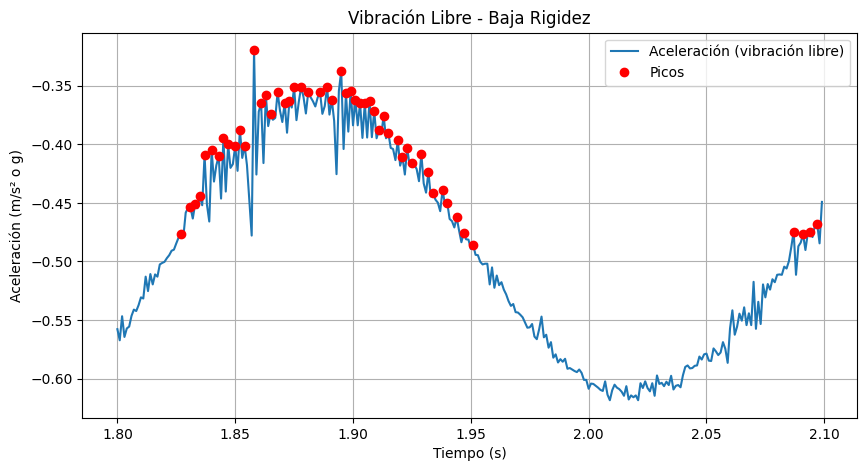

ζ (factor de amortiguamiento) para Baja Rigidez: 0.0077853266095423744

==================== MEDIA RIGIDEZ ====================



C:\Users\miloa\AppData\Local\Temp\ipykernel_11104\159073044.py:38: RuntimeWarning: invalid value encountered in log
  delta = np.log(a1 / a2)


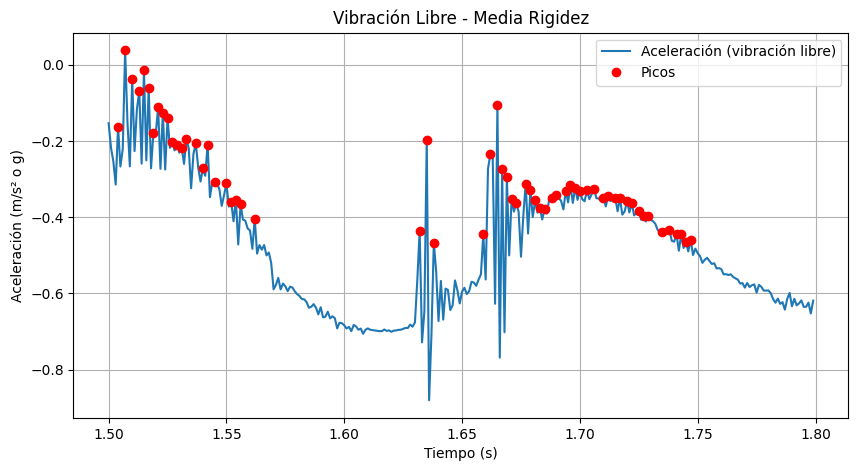

ζ (factor de amortiguamiento) para Media Rigidez: nan

==================== ALTA RIGIDEZ ====================



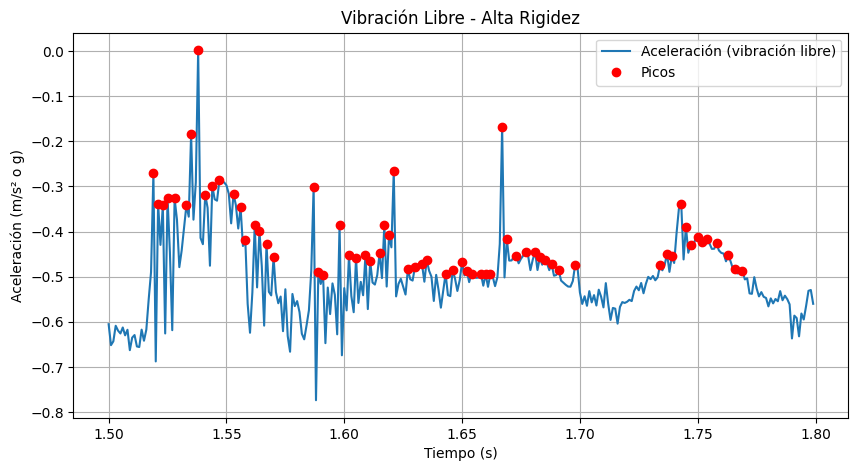

ζ (factor de amortiguamiento) para Alta Rigidez: -0.03567237031656008

========== RESULTADOS FINALES ==========
ζ Baja  = 0.0077853266095423744
ζ Media = nan
ζ Alta  = -0.03567237031656008


In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
# FUNCIONES


def cargar_txt(nombre_archivo):
    return pd.read_csv(
        nombre_archivo,
        sep="\t",
        header=None,
        names=["t", "x", "y"],
        decimal=","
    )

def detectar_vibracion(acc, ventana=300):
    varianzas = []
    for i in range(0, len(acc) - ventana, ventana):
        varianzas.append((i, np.var(acc[i:i+ventana])))

    # Mayor varianza = vibración libre
    inicio = max(varianzas, key=lambda x: x[1])[0]
    fin = inicio + ventana

    return inicio, fin

def calcular_zeta(t, acc):
    peaks, _ = find_peaks(acc, height=np.mean(acc))

    if len(peaks) < 2:
        print("No hay suficientes picos para calcular ζ.")
        return None

    a1 = acc[peaks[0]]
    a2 = acc[peaks[1]]

    delta = np.log(a1 / a2)

    zeta = delta / np.sqrt(4*np.pi**2 + delta**2)

    return zeta, peaks

def procesar_archivo(nombre, titulo):
    print(f"\n==================== {titulo.upper()} ====================\n")

    df = cargar_txt(nombre)

    t = df["t"].values
    acc = df["y"].values  # Eje Y → vibración

    # --- detectar vibración ---
    ini, fin = detectar_vibracion(acc)
    t_vib = t[ini:fin]
    acc_vib = acc[ini:fin]

    # --- calcular zeta ---
    resultado = calcular_zeta(t_vib, acc_vib)

    if resultado is None:
        return None

    zeta, peaks = resultado

    # --- graficar ---
    plt.figure(figsize=(10,5))
    plt.plot(t_vib, acc_vib, label="Aceleración (vibración libre)")
    plt.plot(t_vib[peaks], acc_vib[peaks], "ro", label="Picos")
    plt.title(f"Vibración Libre - {titulo}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Aceleración (m/s² o g)")
    plt.grid()
    plt.legend()
    plt.show()

    print(f"ζ (factor de amortiguamiento) para {titulo}: {zeta}")

    return zeta

# PROCESAMIENTO DE LOS 3 ARCHIVOS 


zeta_baja  = procesar_archivo("carlosgod_baja.txt",  "Baja Rigidez")
zeta_media = procesar_archivo("carlosgod_media.txt", "Media Rigidez")
zeta_alta  = procesar_archivo("carlosgod_alta.txt",  "Alta Rigidez")
# RESULTADOS FINALES


print("\n========== RESULTADOS FINALES ==========")
print("ζ Baja  =", zeta_baja)
print("ζ Media =", zeta_media)
print("ζ Alta  =", zeta_alta)



=== Procesando: Baja  (archivo: carlosgod_baja.txt) ===


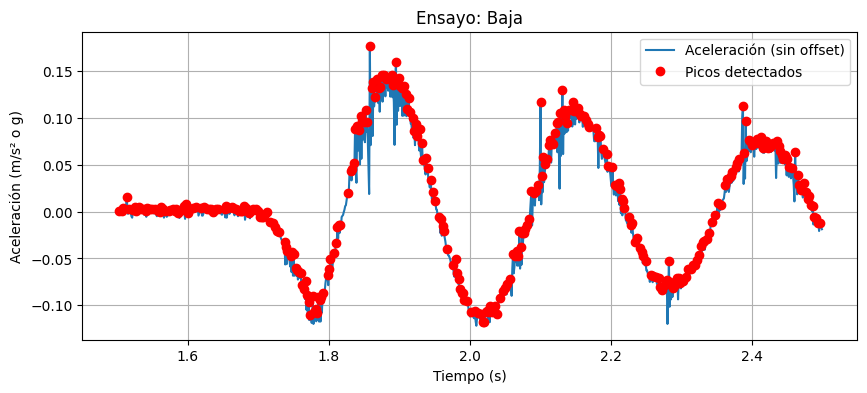

Log-decrement (δ) = 0.00000
Factor de amortiguamiento ζ = 0.00000

=== Procesando: Media  (archivo: carlosgod_media.txt) ===


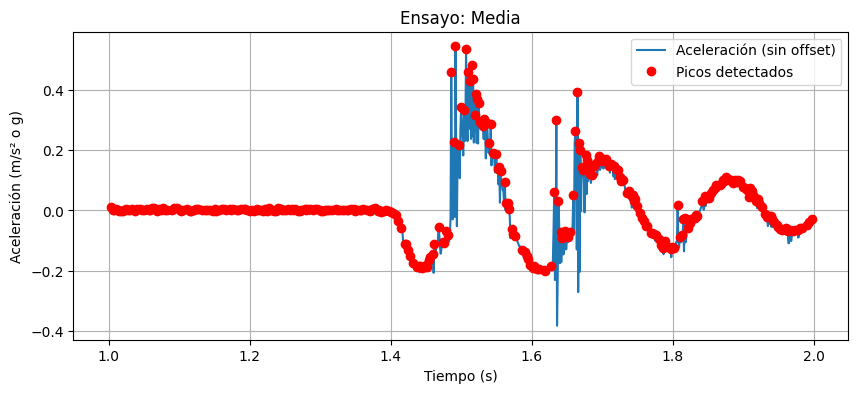

Log-decrement (δ) = 2.09006
Factor de amortiguamiento ζ = 0.31564

=== Procesando: Alta  (archivo: carlosgod_alta.txt) ===


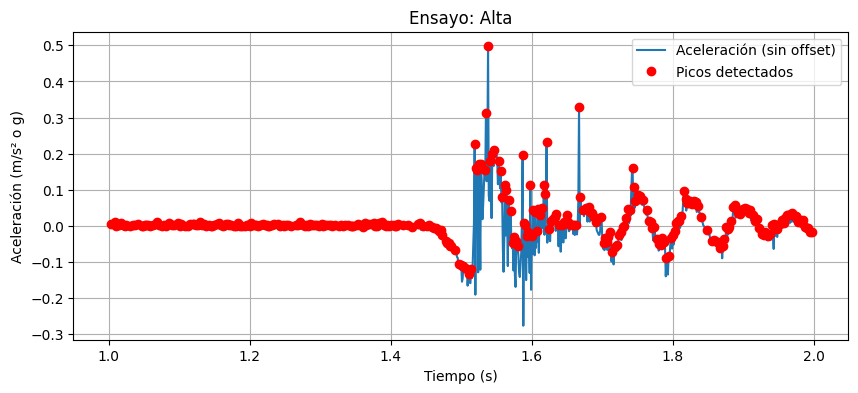

Log-decrement (δ) = -0.89293
Factor de amortiguamiento ζ = -0.14070

=== RESUMEN FINAL ===
Baja: ζ = 0.00000   (δ = 0.00000)
Media: ζ = 0.31564   (δ = 2.09006)
Alta: ζ = -0.14070   (δ = -0.89293)


In [ ]:
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
files = {
    "Baja":  "carlosgod_baja.txt",
    "Media": "carlosgod_media.txt",
    "Alta":  "carlosgod_alta.txt"
}

def cargar_txt(fname):
    df = pd.read_csv(fname, sep="\t", header=None, names=["t","x","y"], decimal=",")
    return df
def remover_offset(acc):
    return acc - np.mean(acc)


# Detectar automáticamente ventana con vibración 
# ventana en muestras 
def detectar_segmento_vibracion(acc, ventana_samples=1000):
    if len(acc) <= ventana_samples:
        return 0, len(acc)
    varianzas = []
    step = ventana_samples // 2
    for i in range(0, len(acc) - ventana_samples + 1, step):
        varianzas.append((i, np.var(acc[i:i+ventana_samples])))
    inicio = max(varianzas, key=lambda x: x[1])[0]
    fin = inicio + ventana_samples
    fin = min(fin, len(acc))
    return inicio, fin


# Calcular zeta 

def calcular_zeta_from_peaks(t_seg, acc_seg, peak_prominence=None):
    # detecta picos positivos
    peaks, props = find_peaks(acc_seg, prominence=peak_prominence)
    if len(peaks) < 2:
        return None, peaks, props
    a1 = acc_seg[peaks[0]]
    a2 = acc_seg[peaks[1]]
    # evitar division por 0 
    if a1 <= 0 or a2 <= 0:
        return None, peaks, props
    delta = np.log(a1 / a2)
    zeta = delta / np.sqrt(4*np.pi**2 + delta**2)
    return (zeta, delta), peaks, props

# Proceso completo por archivo
def procesar_archivo(fname, title, ventana_ms=1000):
    print(f"\n=== Procesando: {title}  (archivo: {fname}) ===")
    df = cargar_txt(fname)
    t = df["t"].values
    acc = df["y"].values.astype(float)

    # quitar offset
    acc = remover_offset(acc)
    ventana_samples = ventana_ms
    ini, fin = detectar_segmento_vibracion(acc, ventana_samples=ventana_samples)
    t_seg = t[ini:fin]
    acc_seg = acc[ini:fin]
    # detectar picos y calcular zeta
    result, peaks, props = calcular_zeta_from_peaks(t_seg, acc_seg, peak_prominence=None)
    # graficar la señal recortada y los picos
    plt.figure(figsize=(10,4))
    plt.plot(t_seg, acc_seg, label="Aceleración (sin offset)")
    if len(peaks) > 0:
        plt.plot(t_seg[peaks], acc_seg[peaks], 'ro', label="Picos detectados")
    plt.title(f"Ensayo: {title}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Aceleración (m/s² o g)")
    plt.grid()
    plt.legend()
    plt.show()

    if result is None:
        print("No se detectaron suficientes picos / amplitudes no válidas para calcular ζ.")
        return None

    zeta, delta = result
    print(f"Log-decrement (δ) = {delta:.5f}")
    print(f"Factor de amortiguamiento ζ = {zeta:.5f}")
    # devolver también la porción de datos y picos
    return {"zeta": zeta, "delta": delta, "t_seg": t_seg, "acc_seg": acc_seg, "peaks_idx": peaks}
# Ejecutar para cada archivo 
results = {}
for title, fname in files.items():
    try:
        results[title] = procesar_archivo(fname, title, ventana_ms=1000)
    except FileNotFoundError:
        print(f"Archivo no encontrado: {fname}  — lo salto (pon el archivo en la carpeta si quieres procesarlo).")
# Mostrar resumen final
print("\n=== RESUMEN FINAL ===")
for title in ["Baja","Media","Alta"]:
    r = results.get(title)
    if r is None:
        print(f"{title}: no calculado")
    else:
        print(f"{title}: ζ = {r['zeta']:.5f}   (δ = {r['delta']:.5f})")



=== Procesando Baja (carlosgod_baja.txt) ===
Frecuencia muestreo estimada: 1000.0 Hz


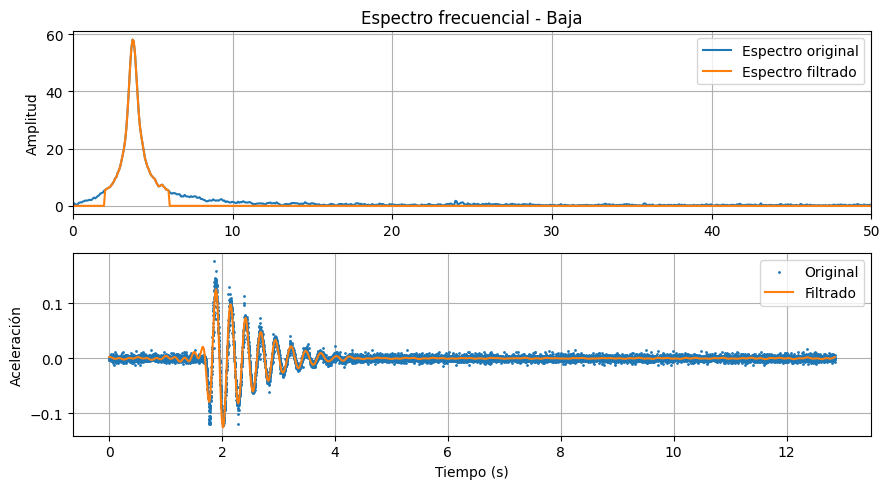

Segmento detectado: 1750 → 2750  (t = 1.750 a 2.749)


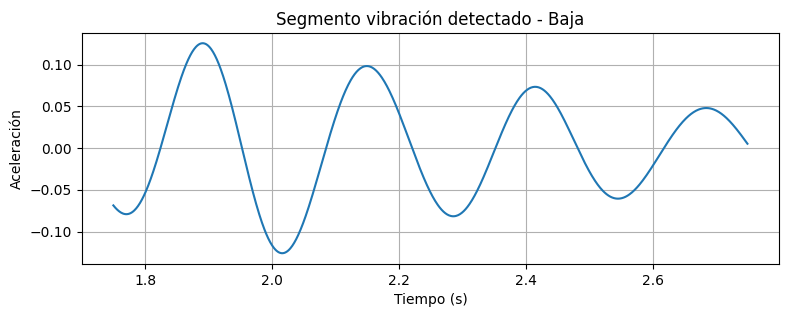

δ = 0.24539
ζ = 0.03903


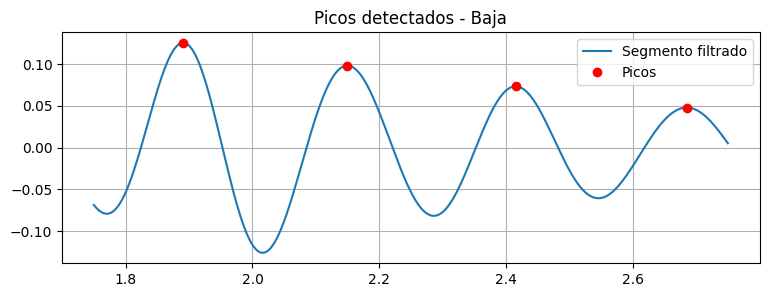


=== Procesando Media (carlosgod_media.txt) ===
Frecuencia muestreo estimada: 1000.0 Hz


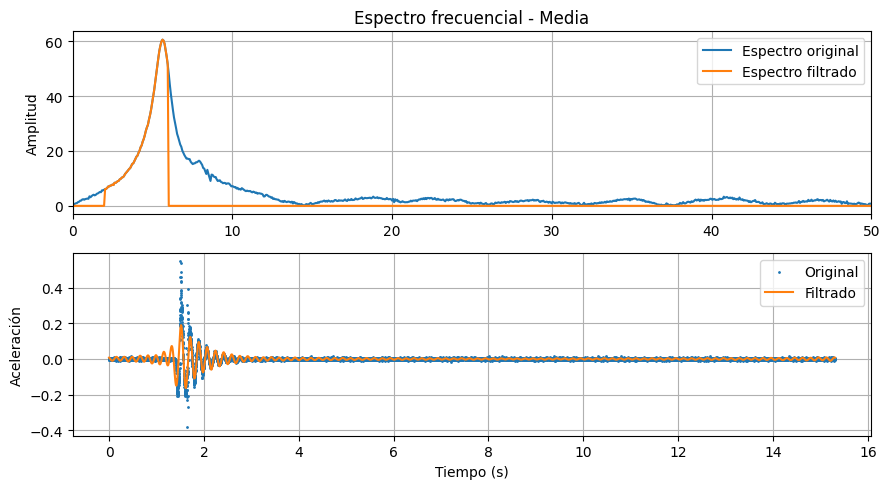

Segmento detectado: 1250 → 2250  (t = 1.250 a 2.249)


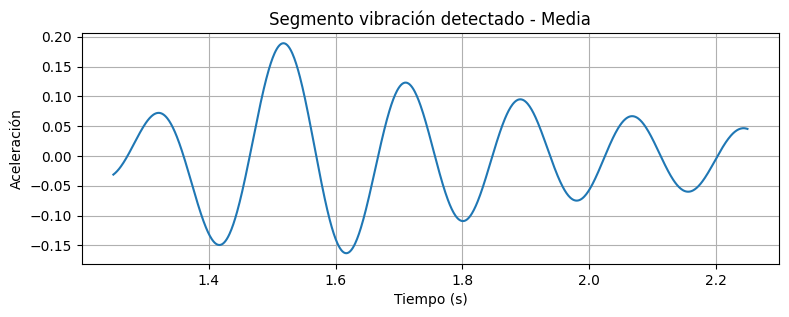

δ = -0.96059
ζ = -0.15113


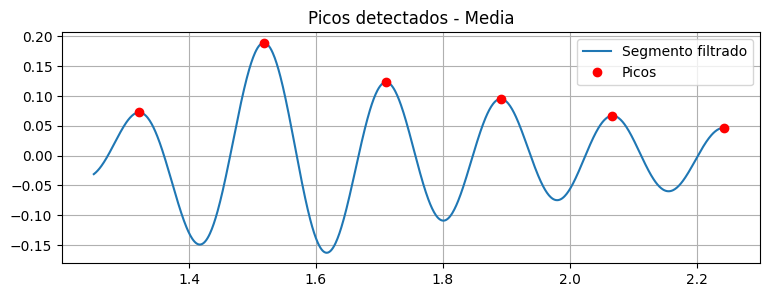


=== Procesando Alta (carlosgod_alta.txt) ===
Frecuencia muestreo estimada: 1000.0 Hz


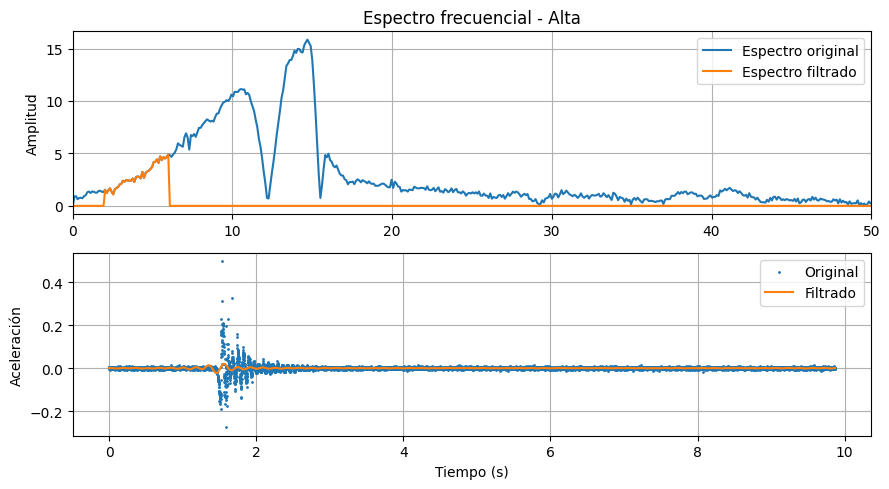

Segmento detectado: 1000 → 2000  (t = 1.000 a 1.999)


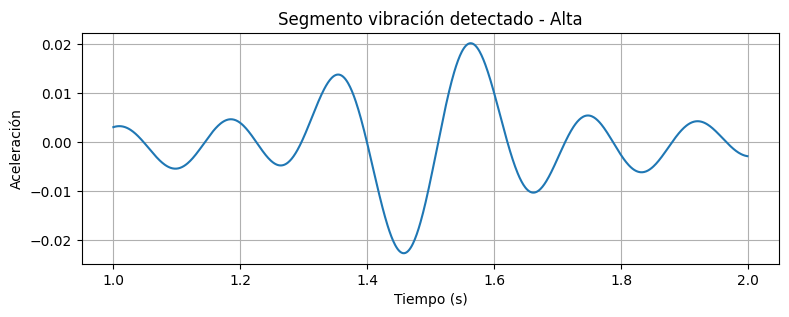

δ = -0.35657
ζ = -0.05666


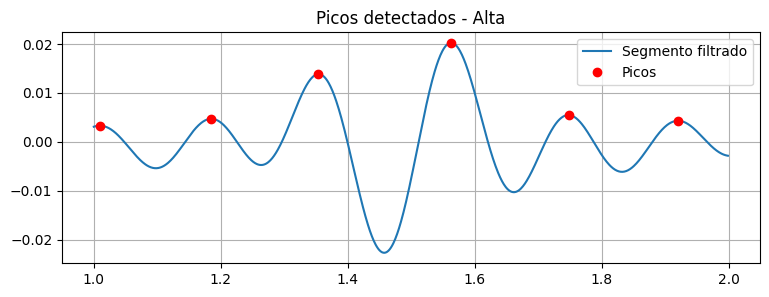


=== RESUMEN FINAL ===
Baja: δ = 0.24539, ζ = 0.03903
Media: δ = -0.96059, ζ = -0.15113
Alta: δ = -0.35657, ζ = -0.05666


In [ ]:
import numpy as np
import pandas as pd
from scipy.fft import fft, ifft
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
files = {
    "Baja":  "carlosgod_baja.txt",
    "Media": "carlosgod_media.txt",
    "Alta":  "carlosgod_alta.txt"
}
# Parámetros
fmin = 2.0     # límite inferior del filtro (Hz)
fmax = 6.0     # límite superior del filtro (Hz)
ventana_samples = 1000   # ~1 segundo si fs ≈ 1000 Hz
peak_prominence = None   # Ajustar si salen muchos picos
convert_g_to_ms2 = False 
# Funciones auxiliares
def cargar_txt(fname):
    return pd.read_csv(fname, sep="\t", header=None, names=["t","x","y"], decimal=",")

def estimar_fs(t):
    dt = np.diff(t)
    return 1.0 / np.mean(dt)

def remover_offset(arr):
    return arr - np.mean(arr)

def fft_bandpass(signal, fs, fmin, fmax):
    N = len(signal)
    Y = fft(signal)
    freqs = np.fft.fftfreq(N, d=1/fs)
    mask = (np.abs(freqs) >= fmin) & (np.abs(freqs) <= fmax)
    Yf = Y * mask
    fil = np.real(ifft(Yf))
    return fil, freqs, Y, Yf, mask

def detectar_segmento(acc, ventana):
    if len(acc) <= ventana:
        return 0, len(acc)
    step = ventana // 4
    varianzas = []
    for i in range(0, len(acc)-ventana+1, step):
        varianzas.append((i, np.var(acc[i:i+ventana])))
    ini = max(varianzas, key=lambda x: x[1])[0]
    fin = min(ini+ventana, len(acc))
    return ini, fin

def zeta_from_peaks(t, acc, prominence=None):
    peaks, props = find_peaks(acc, prominence=prominence)
    if len(peaks) < 2:
        return None, peaks

    a1 = np.abs(acc[peaks[0]])
    a2 = np.abs(acc[peaks[1]])

    if a1 <= 0 or a2 <= 0:
        return None, peaks

    delta = np.log(a1 / a2)
    zeta = delta / np.sqrt(4*np.pi**2 + delta**2)

    return (zeta, delta), peaks
# Procesar archivos
results = {}
for nombre, archivo in files.items():
    print(f"\n=== Procesando {nombre} ({archivo}) ===")
    df = cargar_txt(archivo)

    t = df["t"].astype(float).values
    acc = df["y"].astype(float).values
    if convert_g_to_ms2:
        acc = acc * 9.81
    fs = estimar_fs(t)
    print(f"Frecuencia muestreo estimada: {fs:.1f} Hz")
    acc = remover_offset(acc)
    acc_filt, freqs, Y, Yf, mask = fft_bandpass(acc, fs, fmin, fmax)
    # graficar espectro y señales
    plt.figure(figsize=(9,5))
    pos = freqs >= 0
    plt.subplot(2,1,1)
    plt.plot(freqs[pos], np.abs(Y)[pos], label="Espectro original")
    plt.plot(freqs[pos], np.abs(Yf)[pos], label="Espectro filtrado")
    plt.xlim(0, 50)
    plt.legend()
    plt.grid()
    plt.ylabel("Amplitud")
    plt.title(f"Espectro frecuencial - {nombre}")
    plt.subplot(2,1,2)
    plt.plot(t, acc, '.', markersize=2, label="Original")
    plt.plot(t, acc_filt, '-', label="Filtrado")
    plt.legend()
    plt.grid()
    plt.ylabel("Aceleración")
    plt.xlabel("Tiempo (s)")

    plt.tight_layout()
    plt.show()
    # detectar segmento 
    ini, fin = detectar_segmento(acc_filt, ventana_samples)
    t_seg = t[ini:fin]
    acc_seg = acc_filt[ini:fin]
    print(f"Segmento detectado: {ini} → {fin}  (t = {t_seg[0]:.3f} a {t_seg[-1]:.3f})")
    plt.figure(figsize=(9,3))
    plt.plot(t_seg, acc_seg)
    plt.grid()
    plt.title(f"Segmento vibración detectado - {nombre}")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Aceleración")
    plt.show()
    res, peaks = zeta_from_peaks(t_seg, acc_seg, prominence=peak_prominence)

    if res is None:
        print("No se detectaron suficientes picos.")
        results[nombre] = None
        continue
    zeta, delta = res
    print(f"δ = {delta:.5f}")
    print(f"ζ = {zeta:.5f}")
    plt.figure(figsize=(9,3))
    plt.plot(t_seg, acc_seg, label="Segmento filtrado")
    plt.plot(t_seg[peaks], acc_seg[peaks], 'ro', label="Picos")
    plt.legend()
    plt.grid()
    plt.title(f"Picos detectados - {nombre}")
    plt.show()

    results[nombre] = {"zeta": zeta, "delta": delta}


# Resumen final

print("\n=== RESUMEN FINAL ===")
for nombre in ["Baja","Media","Alta"]:
    if results.get(nombre) is None:
        print(f"{nombre}: NO calculado")
    else:
        print(f"{nombre}: δ = {results[nombre]['delta']:.5f}, ζ = {results[nombre]['zeta']:.5f}")


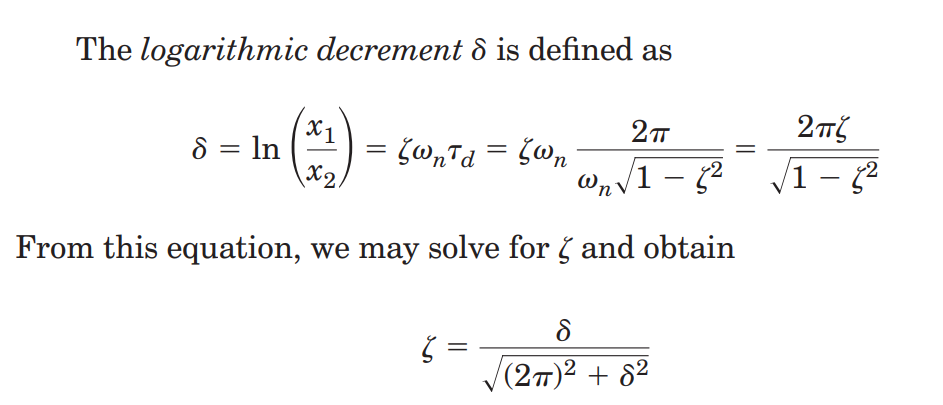


$$
\omega_d = \omega_n \sqrt{1-\zeta^2}
$$

El factor de magnificación para un sistema de 2do orden está dada por:

$$
M = \frac{1}{\sqrt{ (1 - (\frac{\omega}{\omega_n})^2 )^2  + (2 \zeta \frac{\omega}{\omega_n})^2}}
$$
